# Fill a missing AdmR value: one drug

First small run of deliverable D3: fill a `NaN` in the `AdmR` column of `inputs/mode_of_administration.md` for **one drug and one ATC code**.

**Route vocabulary.** `AdmR` is now filled with terms from the FDA route-of-administration legend (`inputs/fda_route_of_administration.tsv`: NAME, DEFINITION, SHORT NAME, FDA CODE, NCI CONCEPT ID). It replaces the WHO DDD letter codes (O, P, N...) the table used before. DailyMed SPL labels record each product's route with the same NCI concept IDs, so the notebook reads the route field from each label and looks it up in the legend directly. Nothing is guessed from label titles.

Rules applied (from the task spec):

- **Rule 3**: at most 2 routes per ATC code, intravenous excluded.
- **Rule 4**: rank routes by how many DailyMed labels report them for this ATC code.
- **Rule 5**: one output row per route.
- **Rule 7**: every label used is listed in `results/` with its DailyMed link, SPL version and a SHA-256 of the XML that was read; the XML itself is kept (gzipped) in `evidence/dailymed/`, and Playwright screenshots of the label and WHO ATC pages go to `evidence/screenshots/`.

The source table is never edited in place; results go to new CSVs.

In [1]:
import datetime, glob, gzip, hashlib, io, json, re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from lxml import etree

DRUG = "azelastine"
ATC = "S01GX07"

HERE = Path.cwd() if (Path.cwd() / "inputs").exists() else Path.cwd() / "curation"
INPUT = HERE / "inputs" / "mode_of_administration.md"
LEGEND = HERE / "inputs" / "fda_route_of_administration.tsv"
EVID = HERE / "evidence"
SPL_DIR = EVID / "dailymed" / DRUG
SHOTS = EVID / "screenshots"
RESULTS = HERE / "results"
for d in (SPL_DIR, SHOTS, RESULTS):
    d.mkdir(parents=True, exist_ok=True)
now = lambda: datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds")

## 1. Load the table and find the row

In [2]:
rows = [l.strip().strip("|").split(" | ") for l in INPUT.read_text().splitlines() if l.startswith("|")]
rows = [[c.strip() for c in r] for r in rows if len(r) >= 4]
admr = pd.DataFrame(rows[2:], columns=rows[0])
print(len(admr), "rows,", (admr.AdmR == "NaN").sum(), "with AdmR = NaN")
admr[admr.GenericName == DRUG]

1167 rows, 315 with AdmR = NaN


,CID,GenericName,ATC,AdmR
11,2267,azelastine,R06AX19,O
12,2267,azelastine,S01GX07,NaN
13,2267,azelastine,R01AC03,N


## 2. The FDA route legend

`inputs/fda_route_of_administration.tsv` is Star's table copied row for row (112 routes). Codes are read as text so FDA codes keep their leading zeros (`012`, not `12`).

In [3]:
legend = pd.read_csv(LEGEND, sep="\t", dtype=str, keep_default_na=False)
assert legend["NCI CONCEPT ID"].is_unique and legend["FDA CODE"].is_unique
print(len(legend), "routes")
legend.head()

112 routes


,NAME,DEFINITION,SHORT NAME,FDA CODE,NCI CONCEPT ID
0,AURICULAR (OTIC),Administration to or by way of the ear.,OTIC,013,C38192
1,BUCCAL,"Administration directed toward the cheek, gene...",BUCCAL,030,C38193
2,CONJUNCTIVAL,"Administration to the conjunctiva, the delicat...",CONJUNC,068,C38194
3,CUTANEOUS,Administration to the skin.,CUTAN,130,C38675
4,DENTAL,Administration to a tooth or teeth.,DENTAL,038,C38197


**Check the legend against its sources.** Two independent checks, so a typo in the copied table would show up:

1. FDA's own SPL route list (fda.gov), matched on NCI concept ID.
2. The NCI Thesaurus (EVS API): every concept ID must exist and be active.

In [4]:
FDA_PAGE = "https://www.fda.gov/industry/structured-product-labeling-resources/route-administration"
html = requests.get(FDA_PAGE, headers={"User-Agent": "Mozilla/5.0"}, timeout=90).text
fda = pd.read_html(io.StringIO(html))[0].astype(str)
fda.columns = ["fda_name", "NCI CONCEPT ID"]
cmp = legend.merge(fda, on="NCI CONCEPT ID", how="outer", indicator=True)
norm = lambda s: s.str.replace("\u2011", "-")   # the pasted EXTRA-AMNIOTIC uses a non-breaking hyphen
both = cmp[cmp._merge == "both"]
print("in both:", len(both), "| name mismatches:", (norm(both.NAME) != both.fda_name).sum())
print("only in Star's legend:", sorted(cmp.loc[cmp._merge == "left_only", "NAME"]))
print("only on FDA's current list:", sorted(cmp.loc[cmp._merge == "right_only", "fda_name"]))

evs = []
ids = legend["NCI CONCEPT ID"].tolist()
for i in range(0, len(ids), 50):
    r = requests.get("https://api-evsrest.nci.nih.gov/api/v1/concept/ncit",
                     params={"list": ",".join(ids[i:i + 50]), "include": "minimal"}, timeout=30)
    evs += r.json()
evs = pd.DataFrame(evs)
print("NCI EVS: found", len(evs), "of", len(ids), "concepts; inactive:", (~evs.active).sum())
cmp.assign(checked_utc=now()).to_csv(RESULTS / "legend_vs_fda_spl_list.csv", index=False)

in both: 107 | name mismatches: 0
only in Star's legend: ['INTRAVENOUS BOLUS', 'INTRAVENOUS DRIP', 'OTHER', 'UNASSIGNED', 'UNKNOWN']
only on FDA's current list: ['INTRACAMERAL', 'INTRACANALICULAR', 'INTRACRANIAL', 'INTRAEPICARDIAL', 'INTRAHEPATIC', 'INTRALINGUAL', 'INTRAMAMMARY', 'INTRANODAL', 'INTRAOMENTUM', 'INTRARUMINAL', 'SUBGINGIVAL', 'SUBRETINAL', 'SUPRACHOROIDAL', 'TRANSENDOCARDIAL']


NCI EVS: found 112 of 112 concepts; inactive: 0


## 3. DailyMed: list the labels, then read each label's route field

The search returns every SPL (label) that mentions the drug. Each SPL's XML is then downloaded and its `<routeCode>` elements are read: these carry the NCI concept ID of the route for each product in the label. A label can list more than one product, so it can carry more than one route.

In [5]:
BASE = "https://dailymed.nlm.nih.gov/dailymed/services/v2"

def dailymed_spls(name):
    out, page = [], 1
    while True:
        j = requests.get(f"{BASE}/spls.json", params={"drug_name": name, "pagesize": 100, "page": page}, timeout=30).json()
        out += [{"setid": d["setid"], "title": d["title"], "spl_version": d["spl_version"],
                 "published_date": d["published_date"]} for d in j["data"]]
        if j["metadata"]["next_page"] in (None, "null"):
            return out
        page += 1

labels = pd.DataFrame(dailymed_spls(DRUG))
print(len(labels), "DailyMed labels mention", DRUG)

47 DailyMed labels mention azelastine


In [6]:
NS = {"v3": "urn:hl7-org:v3"}

def spl_routes(setid):
    raw = requests.get(f"{BASE}/spls/{setid}.xml", timeout=60).content
    (SPL_DIR / f"{setid}.xml.gz").write_bytes(gzip.compress(raw, mtime=0))
    doc = etree.fromstring(raw)
    codes = sorted({e.get("code") for e in doc.iterfind(".//v3:routeCode", NS)})
    names = sorted({e.get("displayName") for e in doc.iterfind(".//v3:routeCode", NS)})
    forms = sorted({e.get("displayName") for e in doc.iterfind(".//v3:manufacturedProduct/v3:manufacturedProduct/v3:formCode", NS)})
    return {"sha256": hashlib.sha256(raw).hexdigest(), "route_nci": codes, "route_name_in_label": names,
            "dosage_form": forms, "retrieved_utc": now()}

labels = labels.join(pd.DataFrame([spl_routes(s) for s in labels.setid]))
labels["source_url"] = "https://dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=" + labels.setid
labels[["title", "dosage_form", "route_name_in_label", "route_nci"]].head(10)

,title,dosage_form,route_name_in_label,route_nci
0,"AZELASTINE HYDROCHLORIDE SPRAY, METERED [CVS P...","[SPRAY, METERED]",[NASAL],[C38284]
1,"AZELASTINE HYDROCHLORIDE SPRAY, METERED [APOTE...","[SPRAY, METERED]",[NASAL],[C38284]
2,AZELASTINE HYDROCHLORIDE SOLUTION/ DROPS [APOT...,[SOLUTION/ DROPS],[INTRAOCULAR],[C38255]
3,AZELASTINE HYDROCHLORIDE AND FLUTICASONE PROPI...,"[SPRAY, METERED]",[NASAL],[C38284]
4,AZELASTINE HYDROCHLORIDE SOLUTION/ DROPS [SAND...,[SOLUTION/ DROPS],[INTRAOCULAR],[C38255]
5,"AZELASTINE HYDROCHLORIDE SPRAY, METERED [AUROH...","[SPRAY, METERED]",[NASAL],[C38284]
6,"AZELASTINE HYDROCHLORIDE SPRAY, METERED [YYBA ...","[SPRAY, METERED]",[NASAL],[C38284]
7,AZELASTINE HYDROCHLORIDE SOLUTION/ DROPS [FOSU...,[SOLUTION/ DROPS],[INTRAOCULAR],[C38255]
8,"AZELASTINE HYDROCHLORIDE SPRAY, METERED [WALGR...","[SPRAY, METERED]",[NASAL],[C38284]
9,"AZELASTINE SPRAY, METERED [ASCEND LABORATORIES...","[SPRAY, METERED]",[NASAL],[C38284]


## 4. Look each route up in the legend

One row per (label, route). A route whose NCI ID is not in the legend is kept and flagged, never dropped silently.

In [7]:
lab = labels.explode("route_nci").rename(columns={"route_nci": "NCI CONCEPT ID"})
lab = lab.merge(legend, on="NCI CONCEPT ID", how="left")
lab["in_legend"] = lab.NAME.notna()
print("label-routes not in the legend:", (~lab.in_legend).sum())
lab.groupby(["NAME", "SHORT NAME", "FDA CODE", "NCI CONCEPT ID"]).size().rename("labels")

label-routes not in the legend: 0


NAME         SHORT NAME  FDA CODE  NCI CONCEPT ID
INTRAOCULAR  I-OCUL      036       C38255             6
NASAL        NASAL       014       C38284            38
OPHTHALMIC   OPHTHALM    012       C38287             3
Name: labels, dtype: int64

### 4b. Cross-check the label's route against its dosage form

The route field is filled in by each manufacturer, and they do not always agree. For azelastine, every eye product is the same dosage form (`SOLUTION/ DROPS`), yet some labels code it `OPHTHALMIC` ("administration to the external eye") and others `INTRAOCULAR` ("administration within the eye", i.e. an injection into the eye). Eye drops cannot be given within the eye, so by the legend's own definitions those labels are mis-coded.

With `CORRECT_EYE_DROPS = True`, a label coded `INTRAOCULAR` whose only dosage forms are drops, solutions, suspensions, ointments, gels or emulsions is counted as `OPHTHALMIC`. The label's own code stays in the provenance file (`route_in_label`), and every corrected label is flagged. Set it to `False` to count the routes exactly as the labels state them.

In [8]:
CORRECT_EYE_DROPS = True
EXTERNAL_EYE_FORMS = {"SOLUTION/ DROPS", "SOLUTION", "SUSPENSION/ DROPS", "SUSPENSION", "OINTMENT", "GEL", "EMULSION"}

lab["route_in_label"] = lab.NAME
topical_only = lab.dosage_form.map(lambda f: bool(f) and set(f) <= EXTERNAL_EYE_FORMS)
fix = CORRECT_EYE_DROPS & (lab.NAME == "INTRAOCULAR") & topical_only
ophth = legend[legend.NAME == "OPHTHALMIC"].iloc[0]
for col in ["NAME", "SHORT NAME", "FDA CODE", "NCI CONCEPT ID"]:
    lab.loc[fix, col] = ophth[col]
lab["route_corrected"] = fix
print(fix.sum(), "labels coded INTRAOCULAR for eye drops were counted as OPHTHALMIC")
lab.groupby(["route_in_label", "NAME", "route_corrected"]).size().rename("labels")

6 labels coded INTRAOCULAR for eye drops were counted as OPHTHALMIC


route_in_label  NAME        route_corrected
INTRAOCULAR     OPHTHALMIC  True                6
NASAL           NASAL       False              38
OPHTHALMIC      OPHTHALMIC  False               3
Name: labels, dtype: int64

## 5. Keep only the routes that belong to this ATC code

A drug can have several ATC codes, and WHO splits them by route (azelastine: R06AX19 oral, R01AC03 nasal, S01GX07 eye). Rule 4 is per ATC code, so a label only counts toward `S01GX07` if its route is an eye route. The map below says which legend routes each ATC group can take; groups that are not in it count every route.

*Assumption, flagged for review:* this map is written by hand from the ATC group names (S01 = ophthalmologicals, S02 = otologicals, R01 = nasal preparations, R03 = drugs for obstructive airway diseases).

In [9]:
ATC_ROUTES = {
    "S01": {"OPHTHALMIC", "CONJUNCTIVAL", "INTRAOCULAR", "INTRAVITREAL", "SUBCONJUNCTIVAL", "RETROBULBAR", "INTRACORNEAL"},
    "S02": {"AURICULAR (OTIC)", "INTRATYMPANIC", "TRANSTYMPANIC"},
    "R01": {"NASAL", "ENDOSINUSIAL", "INTRASINAL"},
    "R03": {"RESPIRATORY (INHALATION)", "ORAL"},
}
allowed = ATC_ROUTES.get(ATC[:3])
lab["counts_for_this_ATC"] = lab.NAME.isin(allowed) if allowed else lab.in_legend
lab.groupby(["NAME", "counts_for_this_ATC"]).size().rename("labels")

NAME        counts_for_this_ATC
NASAL       False                  38
OPHTHALMIC  True                    9
Name: labels, dtype: int64

## 6. Rules 3 and 4: drop intravenous, keep the top 2

In [10]:
IV = {"INTRAVENOUS", "INTRAVENOUS BOLUS", "INTRAVENOUS DRIP"}
counts = Counter(lab.loc[lab.counts_for_this_ATC & ~lab.NAME.isin(IV), "NAME"])
top = counts.most_common(2)
print(f"{ATC}: route counts {dict(counts)} -> keep {top}")
if not top:
    print("No route left after rule 3; this row needs a decision (see 'What is still open').")

S01GX07: route counts {'OPHTHALMIC': 9} -> keep [('OPHTHALMIC', 9)]


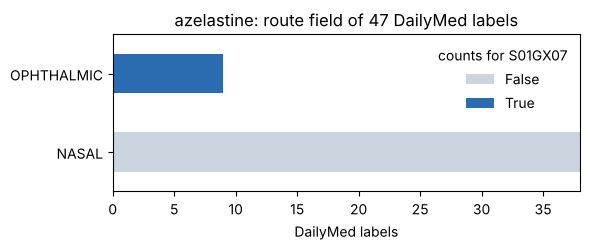

In [11]:
fig, ax = plt.subplots(figsize=(6, 2.6))
c = lab.groupby(["NAME", "counts_for_this_ATC"]).size().unstack(fill_value=0)
c.plot.barh(stacked=True, ax=ax, color={True: "#2b6cb0", False: "#cbd5e0"})
ax.set_xlabel("DailyMed labels"); ax.set_ylabel("")
ax.legend(title=f"counts for {ATC}", frameon=False)
ax.set_title(f"{DRUG}: route field of {len(labels)} DailyMed labels")
fig.tight_layout(); fig.savefig(RESULTS / f"route_counts_{DRUG}.png", dpi=150)

## 7. Rule 5: one row per route, then save

In [12]:
cid = admr.loc[(admr.GenericName == DRUG) & (admr.ATC == ATC), "CID"].iloc[0]
L = legend.set_index("NAME")
out = pd.DataFrame([{
    "CID": cid, "GenericName": DRUG, "ATC": ATC, "AdmR_before": "NaN",
    "AdmR": name, "AdmR_short_name": L.at[name, "SHORT NAME"], "AdmR_fda_code": L.at[name, "FDA CODE"],
    "AdmR_nci_concept_id": L.at[name, "NCI CONCEPT ID"],
    "Edit_Flag": "filled_from_DailyMed_route_field" + (
        f"; {k} label(s) coded INTRAOCULAR corrected" if (k := int(lab.loc[lab.NAME == name, "route_corrected"].sum())) else ""),
    "evidence": f"{n} of {len(labels)} DailyMed labels for {DRUG} list this route",
} for name, n in top])
out.to_csv(RESULTS / f"admr_{DRUG}_{ATC}.csv", index=False)

prov = lab.assign(drug=DRUG, atc=ATC)[["drug", "atc", "setid", "spl_version", "published_date", "title",
    "dosage_form", "route_in_label", "NAME", "FDA CODE", "NCI CONCEPT ID", "route_corrected", "in_legend",
    "counts_for_this_ATC", "source_url", "sha256", "retrieved_utc"]]
prov.to_csv(RESULTS / f"provenance_{DRUG}.csv", index=False)
out

,CID,GenericName,ATC,AdmR_before,AdmR,AdmR_short_name,AdmR_fda_code,AdmR_nci_concept_id,Edit_Flag,evidence
0,2267,azelastine,S01GX07,NaN,OPHTHALMIC,OPHTHALM,012,C38287,filled_from_DailyMed_route_field; 6 label(s) c...,9 of 47 DailyMed labels for azelastine list th...


## 8. Footprints you can check by eye (rule 7)

Playwright opens DailyMed in a real Chromium browser, expands *Ingredients and Appearance*, and screenshots the product table with its **Route of Administration** row: one label for each route code that was counted (so for azelastine, one coded `OPHTHALMIC` and one coded `INTRAOCULAR`). It also screenshots the WHO ATC page for this code, which names the substance it belongs to. The route printed on each DailyMed page is read back and compared with what the XML said, so a mismatch or a page that did not load fails the cell.

In [13]:
from playwright.async_api import async_playwright

def chromium_path():
    found = sorted(glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome"))
    return found[-1] if found else None   # None: use the browser `playwright install chromium` downloaded

counted = prov[prov.counts_for_this_ATC]
picks = counted.drop_duplicates("route_in_label")
shot_log = []
async with async_playwright() as p:
    browser = await p.chromium.launch(executable_path=chromium_path())
    page = await browser.new_page(viewport={"width": 1280, "height": 900})
    for r in picks.itertuples():
        resp = await page.goto(r.source_url, wait_until="domcontentloaded", timeout=60000)
        await page.get_by_text("INGREDIENTS AND APPEARANCE").filter(visible=True).first.click()
        cell = page.locator("td.formLabel", has_text="Route of Administration").first
        await cell.scroll_into_view_if_needed()
        on_page = (await cell.locator("xpath=following-sibling::td[1]").inner_text()).strip()
        fname = f"dailymed_{r.route_in_label.lower()}_{r.setid}.png"
        await page.locator("table", has=cell).first.screenshot(path=SHOTS / fname)
        shot_log.append({"file": f"evidence/screenshots/{fname}", "url": r.source_url, "http_status": resp.status,
                         "route_in_xml": r.route_in_label, "route_on_page": on_page, "taken_utc": now()})
    url = f"https://atcddd.fhi.no/atc_ddd_index/?code={ATC}&showdescription=no"
    resp = await page.goto(url, wait_until="domcontentloaded", timeout=60000)
    fname = f"whocc_{ATC}.png"
    await page.screenshot(path=SHOTS / fname, full_page=True)
    who_text = (await page.inner_text("body")).upper()
    shot_log.append({"file": f"evidence/screenshots/{fname}", "url": url, "http_status": resp.status,
                     "route_in_xml": "", "route_on_page": f"{ATC} {DRUG.upper()} listed: {ATC in who_text and DRUG.upper() in who_text}",
                     "taken_utc": now()})
    await browser.close()

shots = pd.DataFrame(shot_log)
shots.to_csv(RESULTS / f"screenshots_{DRUG}.csv", index=False)
dm = shots[shots.route_in_xml != ""]
assert (dm.route_in_xml == dm.route_on_page).all(), dm
assert shots.iloc[-1].route_on_page.endswith("True"), shots.iloc[-1]
shots

,file,url,http_status,route_in_xml,route_on_page,taken_utc
0,evidence/screenshots/dailymed_intraocular_77a3...,https://dailymed.nlm.nih.gov/dailymed/drugInfo...,200,INTRAOCULAR,INTRAOCULAR,2026-10-09T03:55:46+00:00
1,evidence/screenshots/dailymed_ophthalmic_72406...,https://dailymed.nlm.nih.gov/dailymed/drugInfo...,200,OPHTHALMIC,OPHTHALMIC,2026-10-09T03:55:47+00:00
2,evidence/screenshots/whocc_S01GX07.png,https://atcddd.fhi.no/atc_ddd_index/?code=S01G...,200,,S01GX07 AZELASTINE listed: True,2026-10-09T03:55:48+00:00


evidence/screenshots/dailymed_intraocular_77a33738-ffcf-221c-1562-780418882e5d.png


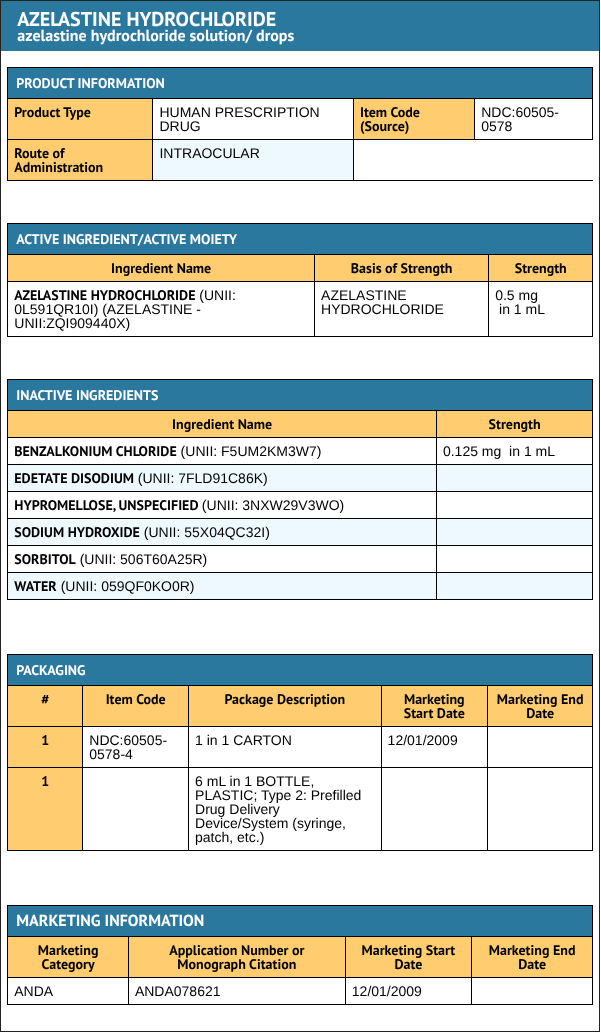

evidence/screenshots/dailymed_ophthalmic_72406ded-7886-41fb-b5c8-2d27a149aa34.png


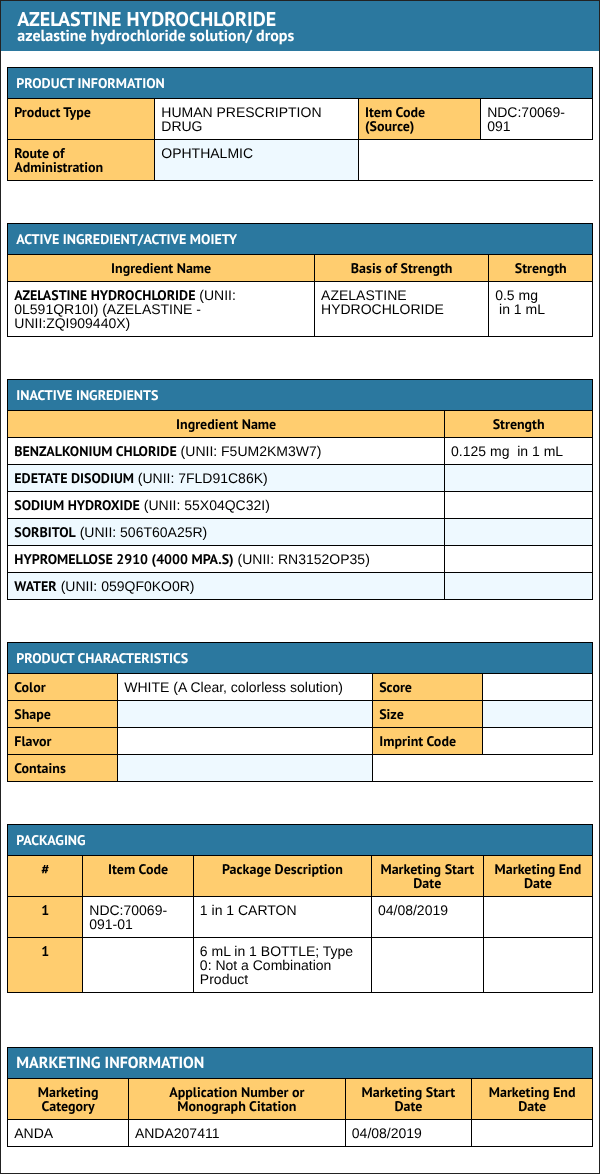

evidence/screenshots/whocc_S01GX07.png


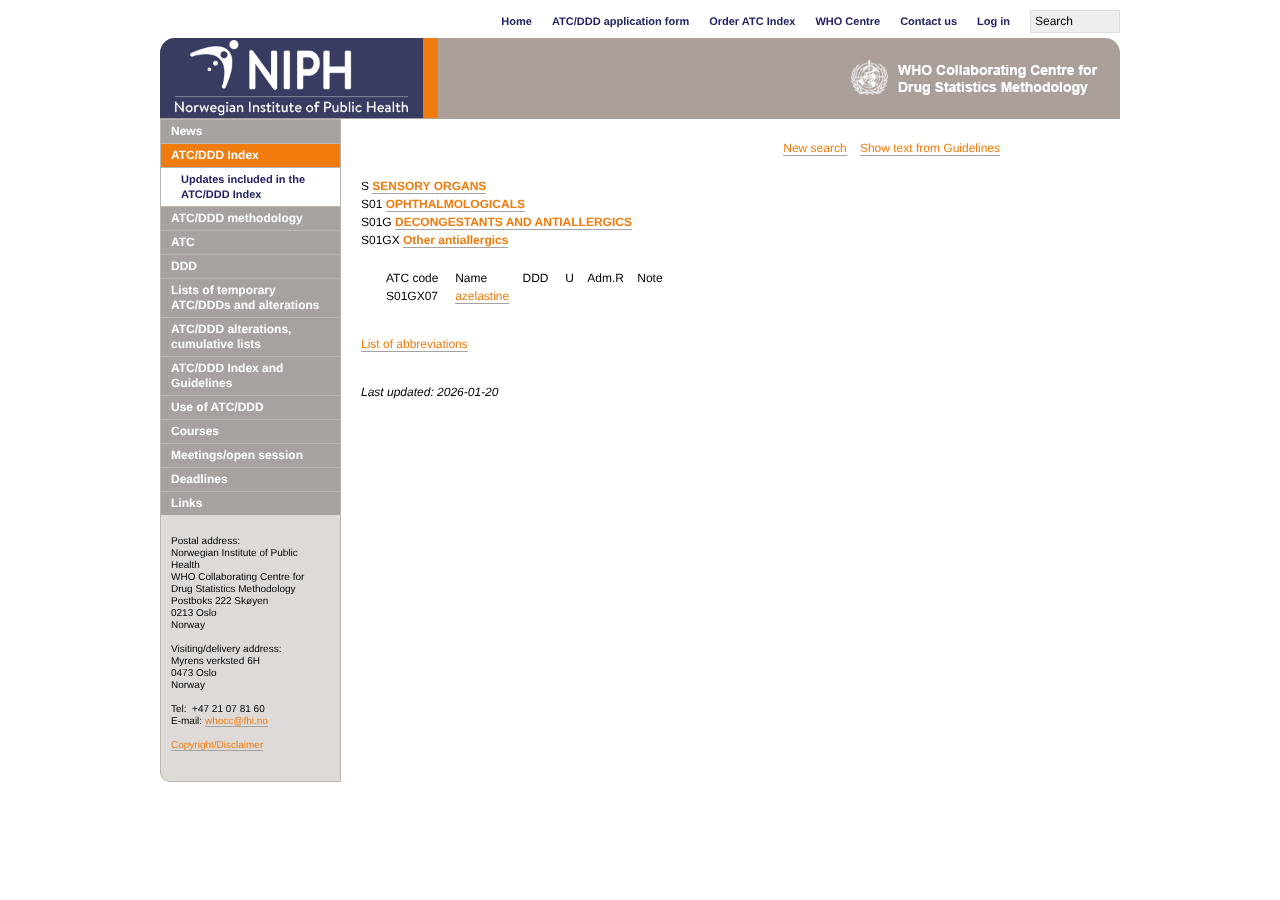

In [14]:
from IPython.display import Image, display
for f in shots.file:
    print(f); display(Image(filename=HERE / f, width=650))

## What is still open

- **IV-only drugs** (e.g. alfentanil, N01AH02): after rule 3 removes intravenous they have no route left. How to record them is waiting on Star.
- **Mis-coded labels** (section 4b): correcting eye drops coded `INTRAOCULAR` to `OPHTHALMIC` is on by default and waiting on Star's confirmation. With it off, azelastine S01GX07 gets two rows (INTRAOCULAR 6 labels, OPHTHALMIC 3).
- **Routes outside the legend.** FDA's current SPL list has 14 routes the legend lacks (e.g. INTRACAMERAL, SUBRETINAL, INTRACRANIAL); a label using one of them is flagged `in_legend = False` in the provenance file. The legend also has 5 terms FDA no longer lists for SPL (INTRAVENOUS BOLUS, INTRAVENOUS DRIP, OTHER, UNASSIGNED, UNKNOWN). Section 2 prints both lists.
- **The `ATC_ROUTES` map** in section 5 is hand-written and only covers a few ATC groups; it needs to grow as more drugs are run.
- **DrugBank** answers automated requests from this cloud session with a Cloudflare bot check (HTTP 403, "Just a moment..."), including from a real Chromium browser, so it was not used. Rule 4's DrugBank count would need its downloadable data release instead.